<h1>04 · Score, Segmentación y Deciles <a id="inicio"> </h1>
<em>Notebook desarrollado por Evelyn Cabrera Arias.</em><br><br>

<b>Repositorio:</b> <code>credit-risk-score</code><br>
<b>Objetivo:</b> Asignar score de morosidad a cada cliente, segmentarlos por nivel de riesgo (Bajo / Medio / Alto) y analizar la distribución por deciles.

<hr>

<h3 style="color: #0d47a1;">Estructura:</h3>

<a href="#seccion-1"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">1. Setup</a>
<a href="#seccion-2"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">2. Construcción del DataFrame de scores</a>
<a href="#seccion-3"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">3. Deciles de score</a>
<a href="#seccion-4"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">4. Visualizaciones de segmentación</a>
<a href="#seccion-5"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">5. Exportar tabla de scores</a>

## 1. Setup <a id="seccion-1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Cargar modelo y datos
modelo   = joblib.load('../models/logistic_regression_scoring.pkl')
X_test   = pd.read_csv('../data/clean/X_test.csv')
y_test   = pd.read_csv('../data/clean/y_test.csv').squeeze()
df_raw   = pd.read_csv('../data/raw/dataset_bank_customer.csv', sep=';')

y_proba = modelo.predict_proba(X_test)[:, 1]
y_pred  = modelo.predict(X_test)
print(f"Clientes en test set: {len(X_test):,}")

Clientes en test set: 2,000


## 2. Construcción del DataFrame de scores <a id="seccion-2"></a>

In [2]:
df_scores = pd.DataFrame({
    'id_cliente':      df_raw.loc[X_test.index, 'id_cliente'].values,
    'score_mora':      y_proba.round(4),
    'prediccion':      y_pred,
    'moroso_real':     y_test.values,
    'segmento_orig':   df_raw.loc[X_test.index, 'segmento_cliente'].values,
    'pais':            df_raw.loc[X_test.index, 'pais'].values,
})

# Segmentación por riesgo — umbrales ajustables según política de la entidad
df_scores['segmento_riesgo'] = pd.cut(
    df_scores['score_mora'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo', 'Medio', 'Alto'],
    include_lowest=True
)

df_scores.head(10)

,id_cliente,score_mora,prediccion,moroso_real,segmento_orig,pais,segmento_riesgo
0,15634602,0.3272,0,0,C,France,Medio
1,15647311,0.5773,1,0,C,Spain,Medio
2,15619304,0.3616,0,0,D,France,Medio
3,15701354,0.3797,0,0,B,France,Medio
4,15737888,0.2934,0,0,A,Spain,Bajo
5,15574012,0.3588,0,0,C,Spain,Medio
6,15592531,0.2847,0,0,A,France,Bajo
7,15656148,0.6372,1,0,D,Germany,Alto
8,15792365,0.6714,1,0,D,France,Alto
9,15592389,0.4713,0,0,B,France,Medio


## 3. Deciles de score <a id="seccion-3"></a>

In [3]:
df_scores['decil'] = pd.qcut(
    df_scores['score_mora'], q=10,
    labels=False, duplicates='drop'
) + 1

resumen_deciles = df_scores.groupby('decil').agg(
    total_clientes=('id_cliente', 'count'),
    total_morosos=('moroso_real', 'sum'),
    score_promedio=('score_mora', 'mean'),
    tasa_mora=('moroso_real', 'mean')
).round(3)

resumen_deciles['tasa_mora_pct'] = (resumen_deciles['tasa_mora'] * 100).round(1)
print("📈 Tabla de deciles:")
print(resumen_deciles.to_string())

📈 Tabla de deciles:
       total_clientes  total_morosos  score_promedio  tasa_mora  tasa_mora_pct
decil                                                                         
1                 200              6           0.124      0.030            3.0
2                 201             14           0.202      0.070            7.0
3                 199             13           0.264      0.065            6.5
4                 200             18           0.323      0.090            9.0
5                 200             19           0.382      0.095            9.5
6                 200             38           0.446      0.190           19.0
7                 200             46           0.516      0.230           23.0
8                 200             52           0.598      0.260           26.0
9                 200             96           0.694      0.480           48.0
10                200            105           0.836      0.525           52.5


## 4. Visualizaciones de segmentación <a id="seccion-4"></a>

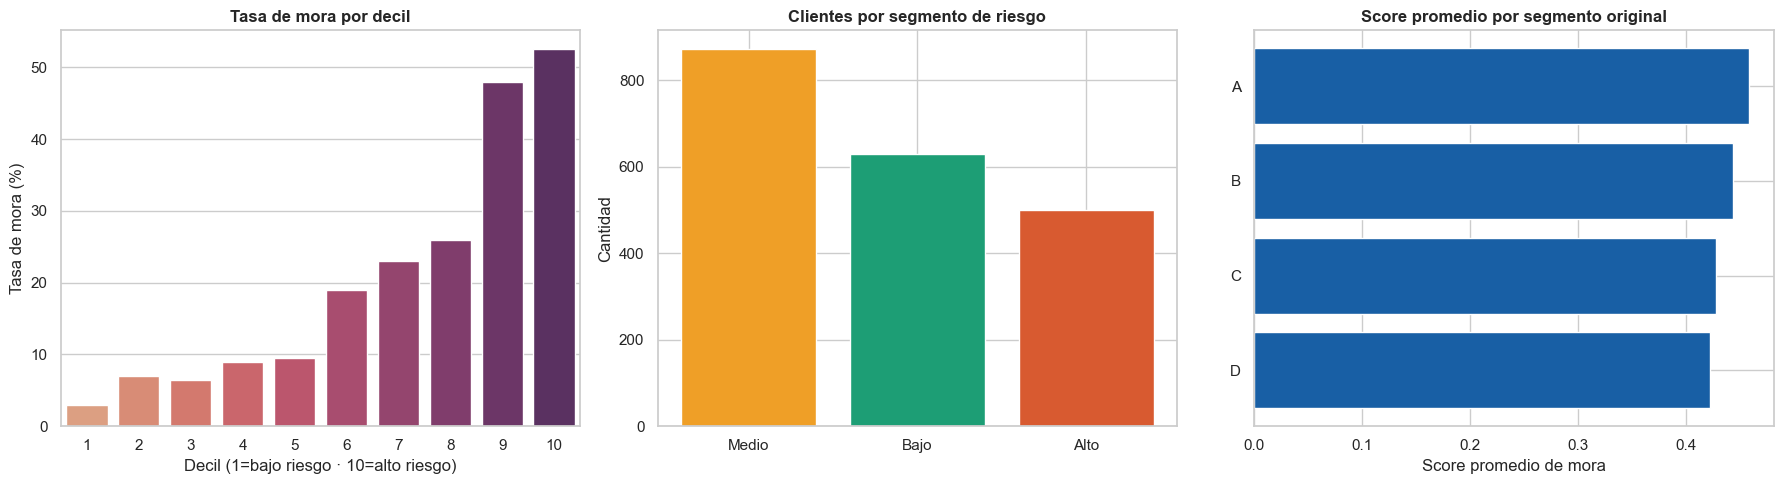

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tasa de mora por decil
sns.barplot(x=resumen_deciles.index, y=resumen_deciles['tasa_mora_pct'],
            palette='flare', ax=axes[0])
axes[0].set_title('Tasa de mora por decil', fontweight='bold')
axes[0].set_xlabel('Decil (1=bajo riesgo · 10=alto riesgo)')
axes[0].set_ylabel('Tasa de mora (%)')

# Distribución por segmento de riesgo
seg_counts = df_scores['segmento_riesgo'].value_counts()
colors_seg = {'Bajo':'#1D9E75','Medio':'#EF9F27','Alto':'#D85A30'}
axes[1].bar(seg_counts.index, seg_counts.values,
            color=[colors_seg[s] for s in seg_counts.index], edgecolor='white')
axes[1].set_title('Clientes por segmento de riesgo', fontweight='bold')
axes[1].set_ylabel('Cantidad')

# Score promedio por segmento cliente original
seg_orig = df_scores.groupby('segmento_orig')['score_mora'].mean().sort_values()
axes[2].barh(seg_orig.index, seg_orig.values, color='#185FA5', edgecolor='white')
axes[2].set_title('Score promedio por segmento original', fontweight='bold')
axes[2].set_xlabel('Score promedio de mora')

plt.tight_layout()
plt.savefig('../outputs/plots/04_score_segmentos.png', dpi=150)
plt.show()

## 5. Exportar tabla de scores <a id="seccion-5"></a>

In [5]:
df_scores.to_csv('../outputs/scores/score_clientes.csv', index=False)
resumen_deciles.to_csv('../outputs/scores/resumen_deciles.csv')
print("✅ Exportado → /outputs/scores/score_clientes.csv")
print("✅ Exportado → /outputs/scores/resumen_deciles.csv")
print(f"\nResumen por segmento de riesgo:")
print(df_scores.groupby('segmento_riesgo').agg(
    clientes=('id_cliente','count'),
    tasa_mora=('moroso_real','mean')
).round(3).to_string())

✅ Exportado → /outputs/scores/score_clientes.csv
✅ Exportado → /outputs/scores/resumen_deciles.csv

Resumen por segmento de riesgo:
                 clientes  tasa_mora
segmento_riesgo                     
Bajo                  629      0.056
Medio                 871      0.161
Alto                  500      0.464


<h3 style="color: #0d47a1;">Siguiente paso: </h3>
`05_estrategias.ipynb`
<em><a href="#inicio"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Volver a inicio de 04_score_segmentos</a></em>